In [ ]:
# ===============================
# 📦 Cell 1: Install Dependencies
# ===============================
!pip install transformers accelerate torch torchvision scikit-learn matplotlib seaborn --quiet

In [ ]:
# ===============================
# 🔄 Cell 2: Setup & Model Loading
# ===============================
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image
import torch
import os
from google.colab import drive
import pandas as pd
from datetime import datetime
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import logging
from tqdm import tqdm
import gc

logging.getLogger("transformers").setLevel(logging.ERROR)

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Paths
base_path = '/content/drive/MyDrive/TRB2026_sharmin/css-data'
subfolders = ['test', 'valid']

Mounted at /content/drive


In [ ]:
# Load BLIP-2 model with error handling
# model_version = "Salesforce/blip2-opt-2.7b"
model_version = "Salesforce/blip2-flan-t5-xl"
try:
    processor = Blip2Processor.from_pretrained(model_version)
    model = Blip2ForConditionalGeneration.from_pretrained(
        model_version,
        torch_dtype=torch.float16,
        device_map="auto"  # Better GPU memory management
    )
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"✅ Model loaded successfully on {device}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    raise

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/5.81G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

✅ Model loaded successfully on cuda


In [ ]:
# Helper: ask VQA with better error handling and memory management
# def ask_question(image_path, question):
#         image = Image.open(image_path).convert("RGB")

#         # Step 1: Generate caption
#         caption_prompt = "Describe all visible construction safety equipment and people in the image."
#         # caption_prompt = "Describe the image in detail."
#         cap_inputs = processor(images=image, text=caption_prompt, return_tensors="pt").to(model.device, torch.float16)
#         cap_output = model.generate(**cap_inputs)
#         caption = processor.decode(cap_output[0], skip_special_tokens=True).strip()

#         # Step 2: Use caption as context for VQA
#         full_prompt = f"Image description: {caption} Question: {question} Answer:"
#         qa_inputs = processor(images=image, text=full_prompt, return_tensors="pt").to(model.device, torch.float16)
#         qa_output = model.generate(**qa_inputs)
#         answer = processor.decode(qa_output[0], skip_special_tokens=True).strip()

#         return "yes" if answer.lower().startswith("yes") else "no"

In [ ]:
# # Helper: ask VQA with better error handling and memory management
def ask_question(image_path, question):
    try:
        image = Image.open(image_path).convert("RGB")
        formatted_question = f"Question: {question} Answer:"

        # Move inputs to correct device and dtype
        inputs = processor(images=image, text=formatted_question, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate with better parameters
        with torch.no_grad():  # Save memory
            output = model.generate(
                **inputs,
                max_new_tokens = 20,
                do_sample=False,  # Deterministic output
                pad_token_id=processor.tokenizer.pad_token_id
            )

        answer = processor.decode(output[0], skip_special_tokens=True)

        # Clean up tensors
        del inputs, output
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

        # More robust answer parsing
        answer_lower = answer.lower()
        return "yes" if "yes" in answer_lower else "no"

    except Exception as e:
        print(f"❌ Error processing {image_path}: {e}")
        return "no"  # Default to negative if error

In [ ]:
# Declare result folder name (change per run if needed)
result_folder_name = "result_blip_exp4_t5"

In [ ]:
# Prompts per label
label_prompts =  {
    0: "Does the image show a worker complying with helmet safety by wearing a hardhat?",
    7: "Is the worker wearing a reflective safety vest as required?",
    6: "Is a safety cone placed to mark a hazardous area?",
    8: "Is any construction machinery like a bulldozer or excavator visible?",
    9: "Is a construction vehicle such as a truck or crane visible in the image?"
}

# Label name mapping for readable summaries
label_names = {
    0: "Helmet",
    7: "Safety Vest",
    6: "Safety Cone",
    8: "Machinery",
    9: "Vehicle"
}

In [ ]:
# ===============================
# 🧠 Cell 3: Inference & Label Saving
# ===============================
total_images = 0
processed_images = 0

for sub in subfolders:
    image_folder = os.path.join(base_path, sub, "images")
    output_label_folder = os.path.join(base_path, sub, result_folder_name)

    # Check if folders exist
    if not os.path.exists(image_folder):
        print(f"⚠️  Warning: {image_folder} does not exist. Skipping...")
        continue

    os.makedirs(output_label_folder, exist_ok=True)

    # Get list of image files
    image_files = [f for f in os.listdir(image_folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]

    print(f"📁 Processing {len(image_files)} images in {sub} folder...")

    for img_file in tqdm(image_files, desc=f"Processing {sub}"):
        total_images += 1
        img_path = os.path.join(image_folder, img_file)

        # Check if file exists and is readable
        if not os.path.exists(img_path):
            print(f"⚠️  Warning: {img_path} does not exist. Skipping...")
            continue

        predicted_labels = []

        for label_id, prompt in label_prompts.items():
            response = ask_question(img_path, prompt)
            if response == "yes":
                predicted_labels.append(label_id)

        predicted_labels = sorted(set(predicted_labels))
        label_filename = os.path.splitext(img_file)[0] + ".txt"
        output_path = os.path.join(output_label_folder, label_filename)

        try:
            with open(output_path, 'w') as f:
                for label in predicted_labels:
                    f.write(f"{label}\n")
            processed_images += 1
        except Exception as e:
            print(f"❌ Error writing labels for {img_file}: {e}")

print(f"✅ BLIP-2 predictions saved to '{result_folder_name}' folders.")
print(f"📊 Processed {processed_images}/{total_images} images successfully.")

📁 Processing 82 images in test folder...


Processing test: 100%|██████████| 82/82 [01:21<00:00,  1.00it/s]


📁 Processing 114 images in valid folder...


Processing valid: 100%|██████████| 114/114 [01:55<00:00,  1.01s/it]

✅ BLIP-2 predictions saved to 'result_blip_exp4_t5' folders.
📊 Processed 196/196 images successfully.


In [ ]:
# Create export directory with timestamp
now = datetime.now().strftime("%Y%m%d_%H%M%S")
export_dir = os.path.join(base_path, f"{result_folder_name}_" + now)
os.makedirs(export_dir, exist_ok=True)

In [ ]:
# ===============================
# 📊 Cell 4: Evaluation & Visualization
# ===============================
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report

true_labels, pred_labels = [], []
skipped_files = []

for sub in subfolders:
    image_dir = os.path.join(base_path, sub, "images")
    gt_dir = os.path.join(base_path, sub, "labels_superclean_GT")
    pred_dir = os.path.join(base_path, sub, result_folder_name)

    # Check if directories exist
    if not all(os.path.exists(d) for d in [image_dir, gt_dir, pred_dir]):
        print(f"⚠️  Warning: Missing directories for {sub}. Skipping evaluation...")
        continue

    image_files = [f for f in os.listdir(image_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]

    for file in image_files:
        name = os.path.splitext(file)[0]
        gt_path = os.path.join(gt_dir, name + ".txt")
        pr_path = os.path.join(pred_dir, name + ".txt")

        if not os.path.exists(gt_path) or not os.path.exists(pr_path):
            skipped_files.append(file)
            continue

        try:
            # Read ground truth labels
            with open(gt_path) as f:
                gt = [int(x.strip()) for x in f if x.strip().isdigit()]

            # Read predicted labels
            with open(pr_path) as f:
                pr = [int(x.strip()) for x in f if x.strip().isdigit()]

            true_labels.append(gt)
            pred_labels.append(pr)

        except Exception as e:
            print(f"❌ Error reading labels for {file}: {e}")
            skipped_files.append(file)

print(f"📊 Evaluation dataset: {len(true_labels)} samples")
if skipped_files:
    print(f"⚠️  Skipped {len(skipped_files)} files due to missing labels")

# Check if we have data for evaluation
if not true_labels:
    print("❌ No valid data found for evaluation. Check your file paths and label formats.")
    exit()

📊 Evaluation dataset: 196 samples


In [ ]:
# Initialize MultiLabelBinarizer with all possible labels
mlb = MultiLabelBinarizer(classes=sorted(label_prompts.keys()))
y_true = mlb.fit_transform(true_labels)
y_pred = mlb.transform(pred_labels)

# Per-label Micro/Macro Evaluation
micro_precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
micro_recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

# Classification report
report = classification_report(
    y_true, y_pred,
    target_names=[label_names[l] for l in mlb.classes_],
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).T.round(3)
report_df_path = os.path.join(export_dir, "classification_report.csv")
report_df.to_csv(report_df_path)

# Print evaluation summary
print("\n✅ Evaluation Summary")
print("="*50)
print(report_df)
print(f"\nMicro F1: {micro_f1:.3f}, Precision: {micro_precision:.3f}, Recall: {micro_recall:.3f}")
print(f"Macro F1: {macro_f1:.3f}, Precision: {macro_precision:.3f}, Recall: {macro_recall:.3f}")

# Save summary CSV
summary_df = pd.DataFrame({
    'Metric': ['Micro Precision', 'Micro Recall', 'Micro F1', 'Macro Precision', 'Macro Recall', 'Macro F1'],
    'Score': [micro_precision, micro_recall, micro_f1, macro_precision, macro_recall, macro_f1]
}).round(3)
summary_df.to_csv(os.path.join(export_dir, "summary_metrics.csv"), index=False)


✅ Evaluation Summary
              precision  recall  f1-score  support
Helmet            0.368   0.972     0.534     72.0
Safety Cone       0.112   1.000     0.202     21.0
Safety Vest       0.255   1.000     0.407     50.0
Machinery         0.897   0.729     0.805     48.0
Vehicle           0.298   0.548     0.386     31.0
micro avg         0.288   0.869     0.433    222.0
macro avg         0.386   0.850     0.467    222.0
weighted avg      0.423   0.869     0.512    222.0
samples avg       0.273   0.593     0.358    222.0

Micro F1: 0.433, Precision: 0.288, Recall: 0.869
Macro F1: 0.467, Precision: 0.386, Recall: 0.850


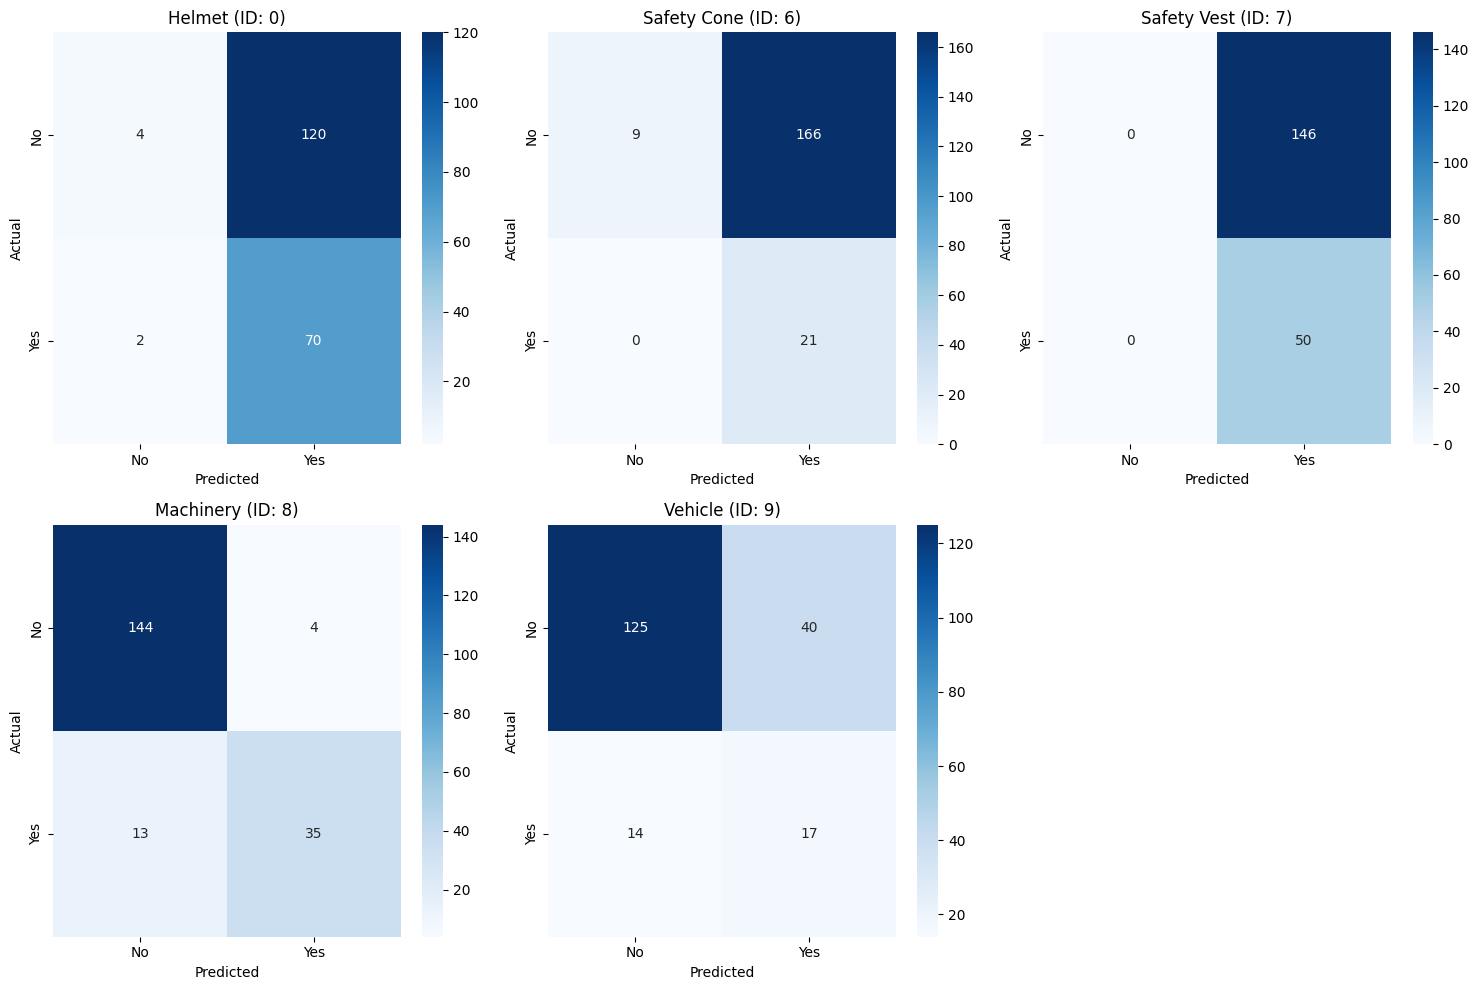

In [ ]:
# Per-label confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, label_id in enumerate(mlb.classes_):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes[i].set_title(f'{label_names[label_id]} (ID: {label_id})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

    # Save each matrix separately
    fig_individual, ax_ind = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_ind,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax_ind.set_title(f'{label_names[label_id]} Confusion Matrix')
    ax_ind.set_xlabel('Predicted')
    ax_ind.set_ylabel('Actual')
    fig_individual.tight_layout()
    fig_individual.savefig(os.path.join(export_dir, f"conf_matrix_label_{label_id}.png"), dpi=300)
    plt.close(fig_individual)

# Hide any unused subplot axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(os.path.join(export_dir, "confusion_matrices_grid.png"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(f"\n📁 Results saved to: {export_dir}")
print("🎉 Evaluation complete!")


📁 Results saved to: /content/drive/MyDrive/TRB2026_sharmin/css-data/result_blip_exp4_t5_20250910_205437
🎉 Evaluation complete!


In [ ]:
# ===============================
# 📝 Cell 5: Log Run Info to Summary Index
# ===============================
import csv
import json
# Summary log file path
summary_log_path = os.path.join(base_path, "experiment_log.csv")

# Define run metadata
experiment_tag = result_folder_name
label_prompts_str = json.dumps(label_prompts, indent=2)  # pretty-print as JSON"Is there{} in the picture?"  # example prompt used
notes = "Standard prompts with safety gear detection"
summary_row = {
    "timestamp": now,
    "experiment": experiment_tag,
    "macro_precision": round(macro_precision, 3),
    "macro_recall": round(macro_recall, 3),
    "macro_f1": round(macro_f1, 3),
    "micro_precision": round(micro_precision, 3),
    "micro_recall": round(micro_recall, 3),
    "micro_f1": round(micro_f1, 3),
    "result_folder": export_dir,
    "model_version": model_version,
    "notes": notes,
    "prompt": label_prompts_str
}

# Write to CSV (append or create)
write_header = not os.path.exists(summary_log_path)
with open(summary_log_path, mode='a', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=list(summary_row.keys()))
    if write_header:
        writer.writeheader()
    writer.writerow(summary_row)

print(f"✅ Experiment log saved to {summary_log_path}")


✅ Experiment log saved to /content/drive/MyDrive/TRB2026_sharmin/css-data/experiment_log.csv
